# All Meter P Correlation Heatmap

- 대상: 전체 계량기 (전기 71 + 열 9)
- feature: `P`
- 기간: `2018-01-01 ~ 2023-12-31`
- 전처리: 없음 (`pd.to_numeric(errors='coerce')`만 적용)
- 집계: 일별 median
- 상관계수: Pearson 절대값 `|corr|`


In [1]:
from __future__ import annotations

from pathlib import Path
import sys

import pandas as pd
import plotly.graph_objects as go

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from config.meter_metadata import load_metadata
from scripts.fetch_h1z16_with_weather import build_engine, fetch_meter_data

TARGET_FEATURE = 'P'
ANALYSIS_YEARS = set(range(2018, 2024))

metadata = load_metadata()
all_meters = sorted(
    meter_urn
    for meter_urn, _info in metadata.items()
)

print(f'all meter count: {len(all_meters)}')
all_meters[:10]


all meter count: 81


['H1.K11',
 'H1.K12',
 'H1.K14',
 'H1.K15',
 'H1.K16',
 'H1.W11',
 'H1.W12',
 'H1.Z10',
 'H1.Z11',
 'H1.Z12']

In [2]:
engine = build_engine()
daily_series_map: dict[str, pd.Series] = {}
skipped: dict[str, str] = {}

for meter_urn in all_meters:
    try:
        df = fetch_meter_data(engine, meter_urn).copy()
    except Exception as exc:
        skipped[meter_urn] = f'fetch failed: {exc}'
        continue

    if TARGET_FEATURE not in df.columns:
        skipped[meter_urn] = f'missing column: {TARGET_FEATURE}'
        continue

    working = df[['ts', TARGET_FEATURE]].copy()
    working['ts'] = pd.to_datetime(working['ts'], utc=True, errors='coerce')
    working[TARGET_FEATURE] = pd.to_numeric(working[TARGET_FEATURE], errors='coerce')
    working = working.dropna(subset=['ts']).sort_values('ts')
    working = working.loc[working['ts'].dt.year.isin(ANALYSIS_YEARS)].copy()

    if working.empty:
        skipped[meter_urn] = 'empty after year filter'
        continue

    daily = (
        working.assign(date=working['ts'].dt.floor('D'))
        .groupby('date')[TARGET_FEATURE]
        .median()
        .sort_index()
    )

    if daily.dropna().shape[0] < 2:
        skipped[meter_urn] = 'not enough usable daily values'
        continue

    daily_series_map[meter_urn] = daily

print(f'usable meters: {len(daily_series_map)}')
print(f'skipped meters: {len(skipped)}')
list(skipped.items())[:10]


usable meters: 80
skipped meters: 1


[('WeatherStation.Weather', 'not enough usable daily values')]

In [3]:
combined = pd.concat(daily_series_map, axis=1)
combined.columns = list(daily_series_map.keys())
corr_abs = combined.corr(method='pearson').abs()
corr_abs = corr_abs.loc[sorted(corr_abs.index), sorted(corr_abs.columns)]

corr_abs.shape


(80, 80)

In [4]:
z_values = corr_abs.round(4).values
text_values = corr_abs.map(lambda value: f'{value:.2f}' if pd.notna(value) else '').values

fig = go.Figure(
    data=[
        go.Heatmap(
            z=z_values,
            x=corr_abs.columns.tolist(),
            y=corr_abs.index.tolist(),
            zmin=0,
            zmax=1,
            colorscale='RdBu_r',
            reversescale=False,
            text=text_values,
            texttemplate='%{text}',
            textfont={'size': 9},
            colorbar={'title': '|corr|'},
            hovertemplate='%{y} vs %{x}: %{z:.3f}<extra></extra>',
        )
    ]
)

fig.update_layout(
    title='All Meters | P Daily Median | Absolute Pearson Correlation',
    width=1400,
    height=1400,
    template='plotly_white',
    xaxis={'side': 'bottom', 'tickangle': -45},
    yaxis={'autorange': 'reversed'},
)

fig.show()


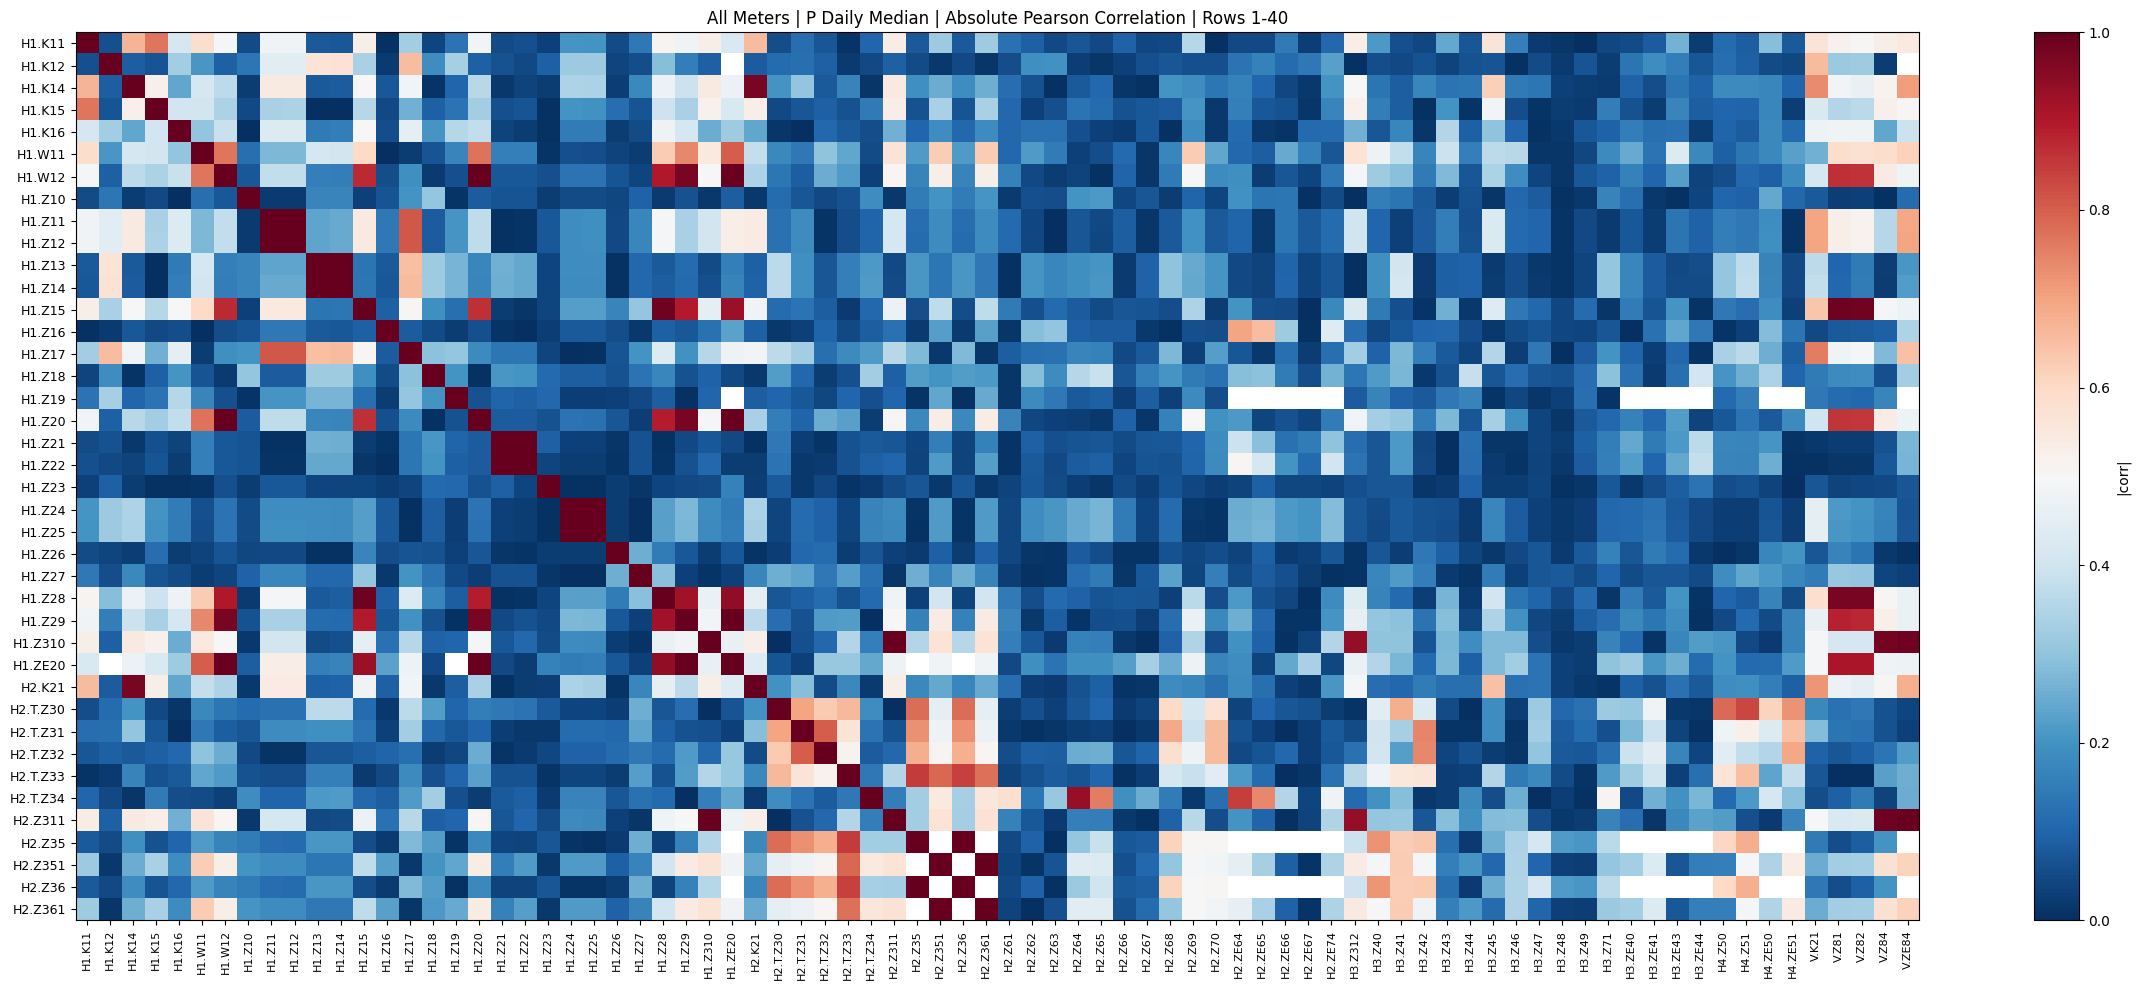

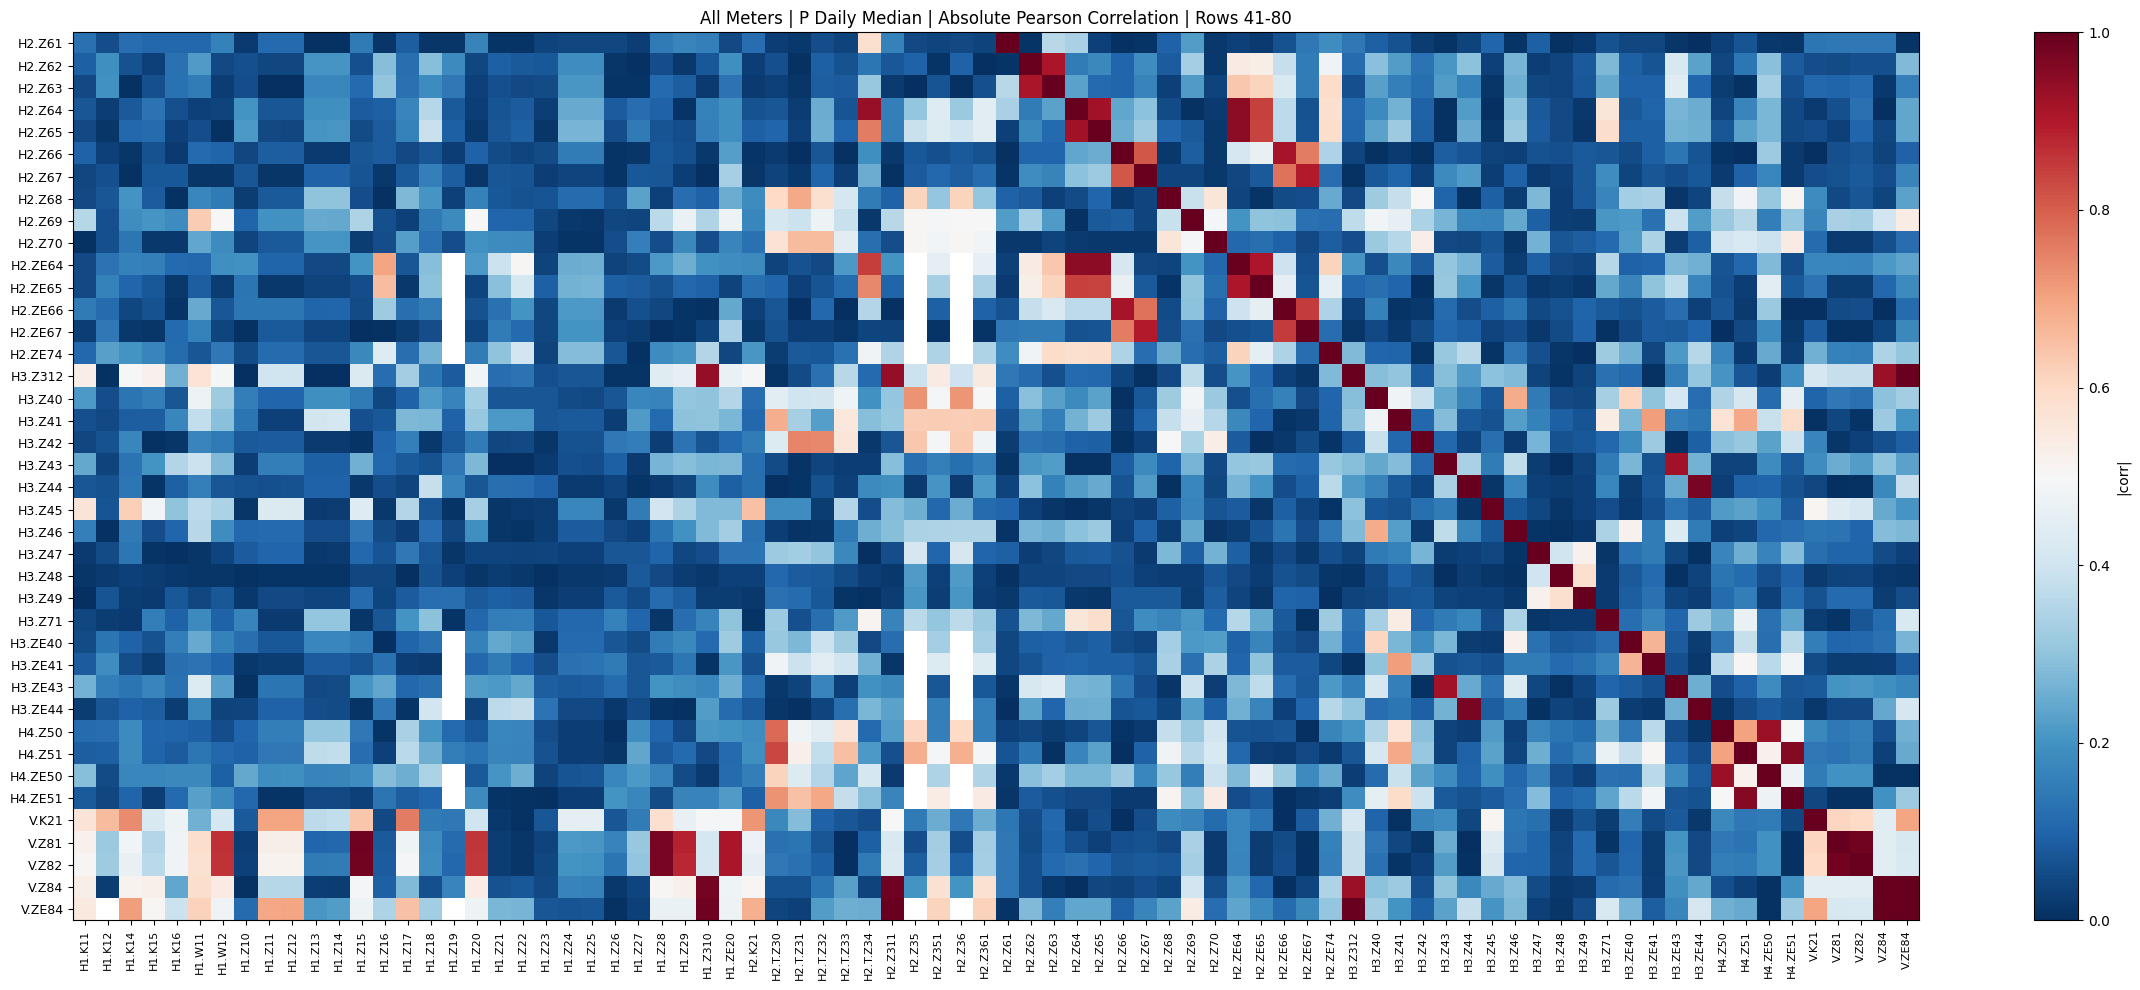

In [4]:
import matplotlib.pyplot as plt

split_at = 40

def render_split_heatmap(row_labels: list[str], title: str) -> None:
    subset = corr_abs.loc[row_labels, :]
    fig, ax = plt.subplots(figsize=(24, 10))
    image = ax.imshow(subset.values, cmap='RdBu_r', vmin=0, vmax=1, aspect='auto')
    ax.set_title(title)
    ax.set_xticks(range(len(subset.columns)))
    ax.set_xticklabels(subset.columns, rotation=90, fontsize=8)
    ax.set_yticks(range(len(subset.index)))
    ax.set_yticklabels(subset.index, fontsize=9)
    fig.colorbar(image, ax=ax, label='|corr|')
    plt.tight_layout()
    plt.show()

render_split_heatmap(corr_abs.index[:split_at].tolist(), 'All Meters | P Daily Median | Absolute Pearson Correlation | Rows 1-40')
render_split_heatmap(corr_abs.index[split_at:].tolist(), 'All Meters | P Daily Median | Absolute Pearson Correlation | Rows 41-80')
